**Question 1**

1. 
Regression is predicting a continuous numerical value. For example, trying to predict the exact price of a house or the temperature tomorrow. Classification is predicting a discrete label or "class", like if an image is dog or cat and if an email is spam or not spam.

2.
The confusion matrix is a table that compares the Predicted Labels against the Actual Labels. It helps us understand the performance of a model by showing us the type of mistakes it makes. It generates a table that show counts of true positives, false positives, true negatives, false negatives.

3.
Accuracy is the ratio of correct predictions to the total number of predictions. It is not entirely sufficient to evaluate a classifer's predictive performance in certain cases. For example, if a dataset had 99% of people as healthy and 1% as having rare disease. A model that always predicts "Healthy" will have 99% accuracy but is totally useless because it never finds the sick people. In cases like this, we need other metrics to evaluate its pedictive performance.

4.
RMSE is the metric for regression, it quantifies the average magnitude of the error. If your RMSE is 10, it means your predictions are on average about 10 units off from the actual value.

5.
Overfitting models has an algorithem that fits too closely with its training data. It's performs great on training data but fails on new, unseen data. On the other hand, underfitting means the model is too simple to capture the underlying trend. It performs poorly on both training and test data.

6.
Splitting the data into training and testing sets helps because it gives us an honest way to check how well the model will work on new data. If we choose k using training accuracy/RMSE, we might pick a very small k (like k = 1) that basically memorizes the training points and looks “perfect” there, but then performs worse on unseen data, resulting in overfitting. Using the test set to evaluate different k values pushes us to choose the k that generalizes best, so the model is less tuned to noise and more reliable in practice.


7. 
For predicting a class label, it is simple, easy to inteperate and evaluate. However, it hides how uncertain then model is in predicting this. The model could have different confidence levels but still result in the same output. The user will not be able to tell which prediction is risky. 
For predicting probability distribution, the user can see the confidence/probability behind the labels and make better decisions about the final label. However, potential weaknesses are that you still have to pick a cutoff to turn probabilities into a single class label, and the probabilities themselves may not be perfectly calibrated, as the model can sound more confident than it should be.

**Question 2**

1.

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [131]:
df = pd.read_csv('land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [132]:
df.isna().sum()

voltage      0
height       0
soil         0
mine_type    0
dtype: int64

In [133]:
df["mine_type"].value_counts()
df["mine_type"].value_counts(normalize=True) 

mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64

In [134]:
df[["voltage","height","soil"]].describe()

df.groupby("mine_type")[["voltage","height","soil"]].agg(["count","mean","std","min","median","max"])


voltage                                                   height  \
            count      mean       std       min    median       max  count   
mine_type                                                                    
1              71  0.296463  0.031672  0.229607  0.296586  0.365861     71   
2              70  0.721123  0.222267  0.362537  0.714501  0.999999     70   
3              66  0.402408  0.098185  0.253776  0.371601  0.752265     66   
4              66  0.345365  0.092564  0.197734  0.336858  0.592144     66   
5              65  0.379598  0.076340  0.229607  0.362537  0.583081     65   

                                                   soil                      \
               mean       std  min    median  max count      mean       std   
mine_type                                                                     
1          0.495519  0.315962  0.0  0.454545  1.0    71  0.492958  0.341143   
2          0.487013  0.310720  0.0  0.454545  1.0    70  0.508571  0.345045   
3          0.527548  0.296288  0.0  0.545455  1.0    66  0.496970  0.351248   
4          0.506887  0.306348  0.0  0.545455  1.0    66  0.503030  0.347727   
5          0.530070  0.306426  0.0  0.545455  1.0    65  0.516923  0.346216   

                            
           min median  max  
mine_type                   
1          0.0    0.4  1.0  
2          0.0    0.6  1.0  
3          0.0    0.5  1.0  
4          0.0    0.5  1.0  
5          0.0    0.6  1.0

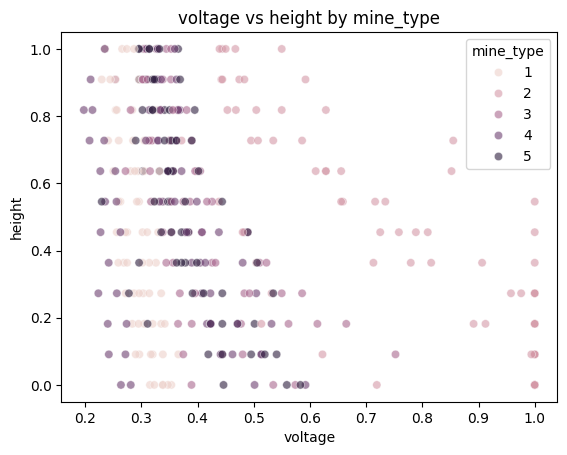

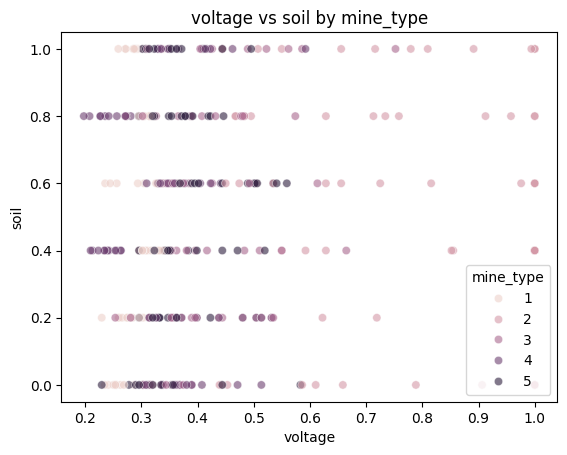

In [135]:
sns.scatterplot(data=df, x="voltage", y="height", hue="mine_type", alpha=0.6)
plt.title("voltage vs height by mine_type")
plt.show()

sns.scatterplot(data=df, x="voltage", y="soil", hue="mine_type", alpha=0.6)
plt.title("voltage vs soil by mine_type")
plt.show()

2.

In [136]:
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]


In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=100,
    stratify=y 
)


3.

In [138]:
from sklearn.neighbors import KNeighborsClassifier


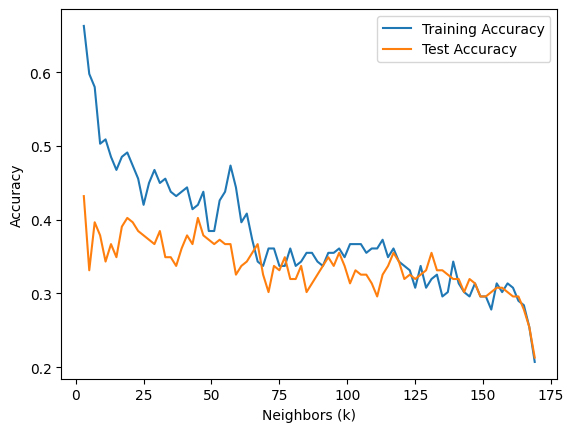

In [139]:
n_train = len(X_train)
k_grid = np.array([(2*k+3) for k in range(0,150)])   # 3,5,7,...
k_grid = k_grid[k_grid <= n_train]                   

test_accuracies = []
train_accuracies = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    test_accuracies.append(model.score(X_test, y_test))
    train_accuracies.append(model.score(X_train, y_train))

sns.lineplot(x=k_grid, y=train_accuracies, label="Training Accuracy")
sns.lineplot(x=k_grid, y=test_accuracies, label="Test Accuracy")
plt.xlabel("Neighbors (k)")
plt.ylabel("Accuracy")
plt.show()

In [140]:
k_star = k_grid[np.argmax(test_accuracies)]
best_test_acc = np.max(test_accuracies)
k_star, best_test_acc

(np.int64(3), np.float64(0.4319526627218935))

I selected k by looping over a grid of odd k values and choosing the k that maximized test-set accuracy; the best value was k=3 with test accuracy ≈ 0.432
Training accuracy was higher for small k, but we use test accuracy to avoid overfitting

4.

In [141]:
from sklearn.metrics import confusion_matrix, accuracy_score

model_best = KNeighborsClassifier(n_neighbors=int(k_star))
model_best.fit(X_train, y_train)

y_hat = model_best.predict(X_test)

cm = confusion_matrix(y_test, y_hat)
acc = accuracy_score(y_test, y_hat)

cm


array([[24,  0,  6,  3,  3],
       [ 1, 29,  2,  2,  1],
       [15,  3,  8,  1,  6],
       [10,  4, 10,  8,  1],
       [14,  1, 12,  1,  4]])

In [142]:
acc

0.4319526627218935

The model gets about 43% accuracy overall, performs best on class 2 (29 / 35 ~ around 83% correct), is decent on class 1, and struggles heavily on classes 3–5, which are often misclassified as class 1 or class 3.

5.

I wouldn’t use this model to automatically decide mine type, because even though it’s pretty accurate for one class, the confusion matrix shows it still confuses the other types a lot and overall accuracy is only ~43%. In practice I’d use it as a first-pass screening tool. So I would trust predictions more for the class it’s best at, but treat the classes it often mixes up as uncertain and require a second inspection. So essentially, my advice is to treat the prediction as “high confidence” for the mine type the model is consistently good at predicting, but if it predicts one of the types it often confuses, I’d flag it for follow-up testing instead of labeling it immediately.

**Question 3**

1.

In [143]:
df = pd.read_csv('USA_cars_datasets.csv')
df.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [144]:
df = df[["price", "year", "mileage"]]
df = df.dropna()

In [145]:
df.head()

,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [146]:
df.shape

(2499, 3)

2.

In [147]:
X = df[["year","mileage"]]
y = df["price"]

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

u = X.apply(minmax)

3.

In [148]:
u_train, u_test, y_train, y_test = train_test_split(
    u, y, test_size=0.2, random_state=100
)

4.

In [149]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k = 3: MSE = 126,118,037.16


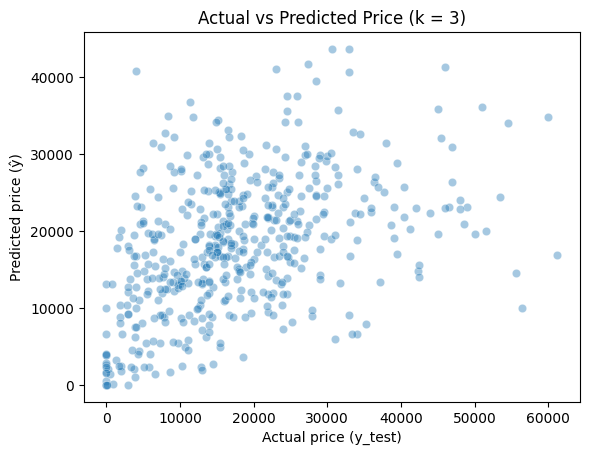

k = 10: MSE = 110,653,044.19


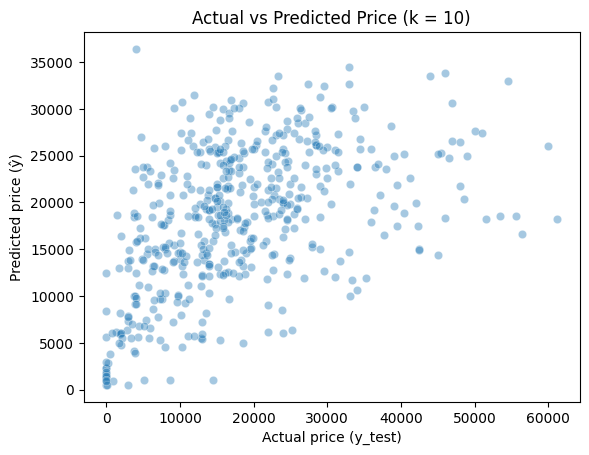

k = 25: MSE = 103,174,289.15


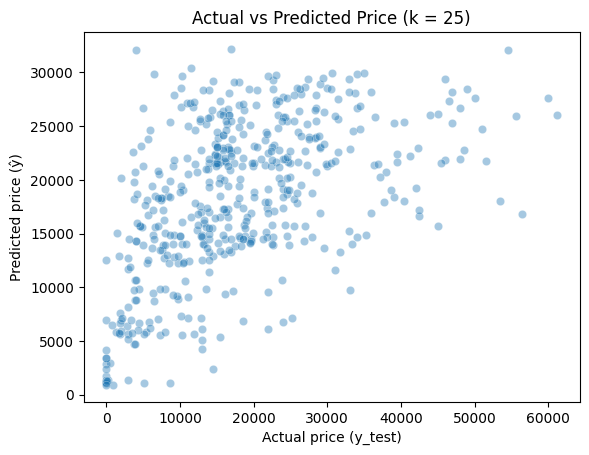

k = 50: MSE = 99,685,489.50


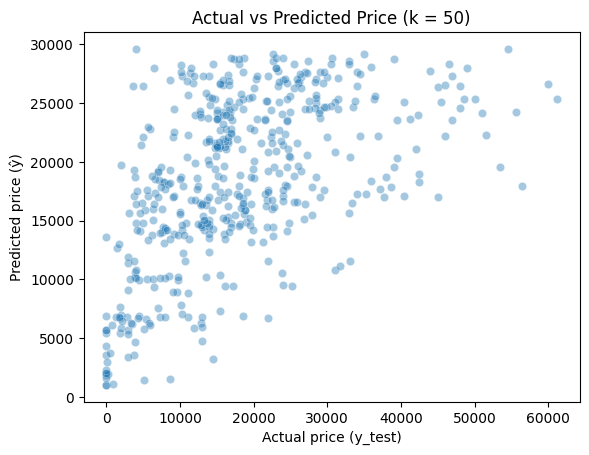

k = 100: MSE = 98,276,515.02


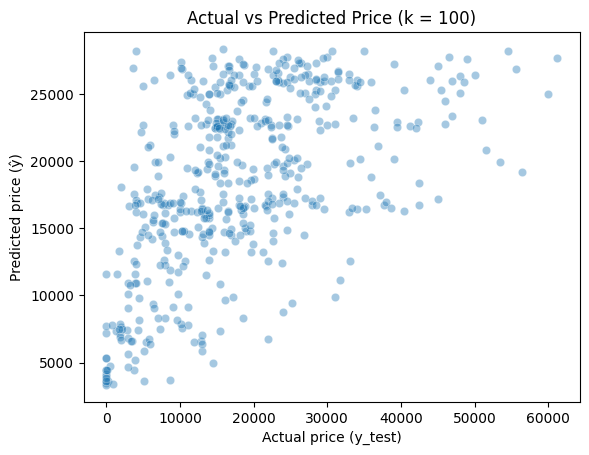

k = 300: MSE = 100,477,298.91


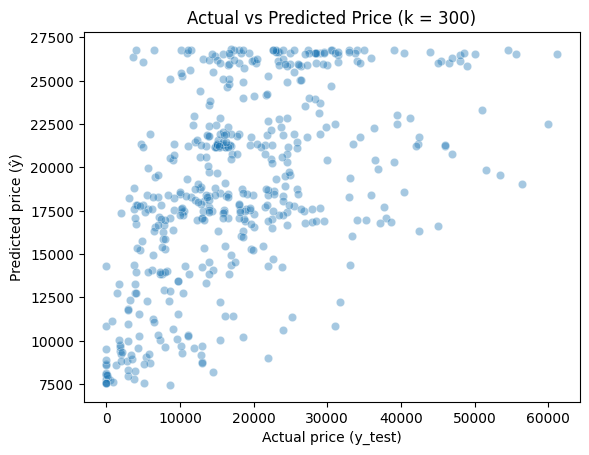

In [150]:
k_list = [3, 10, 25, 50, 100, 300]

mse_list = []

for k in k_list:
    # fit + predict
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(u_train, y_train)
    y_hat = model.predict(u_test)

    # MSE
    mse = mean_squared_error(y_test, y_hat)
    mse_list.append(mse)
    print(f"k = {k}: MSE = {mse:,.2f}")

    # scatterplot: test (actual) vs predicted
    plt.figure()
    sns.scatterplot(x=y_test, y=y_hat, alpha=0.4)
    plt.xlabel("Actual price (y_test)")
    plt.ylabel("Predicted price (ŷ)")
    plt.title(f"Actual vs Predicted Price (k = {k})")
    plt.show()

When (k) is small (like 3), the predictions are more jumpy and sensitive to local noise, so the model can overfit and the test MSE tends to be higher. As (k) increases to around 50–100, predictions smooth out because each estimate averages more neighbors, and the points compress toward the middle; in my results, the test MSE decreased in this range. When (k) is very large (like 300), the model starts to underfit because many predictions become similar, almost like predicting an overall average. The scatterplot looks more like a horizontal band instead of lining up with (y=\hat{y}), and the test MSE increases again.

5.

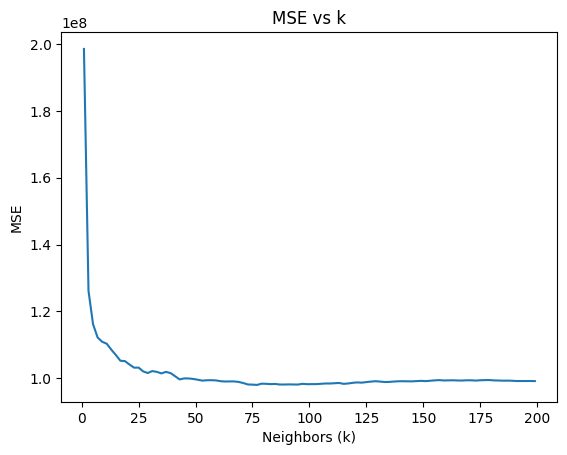

(77, 97993471.39388362)

In [ ]:
#Make a list of candidate ks
k_grid = [(2*k + 1) for k in range(100)]

#Try each k and measure how wrong it is on the test set
mses = []
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(u_train, y_train)
    y_hat = model.predict(u_test)
    mses.append(mean_squared_error(y_test, y_hat))

#Plot MSE vs k
sns.lineplot(x=k_grid, y=mses)
plt.xlabel("Neighbors (k)")
plt.ylabel("MSE")
plt.title("MSE vs k")
plt.show()

#finding optimal k
index_star = np.argmin(mses)
k_star = k_grid[index_star]
mse_star = mses[index_star]

k_star, mse_star

The optimal 𝑘 k is k^* = 77, because it minimizes the test-set MSE (MSE = 97993471.39388362) over the grid of candidate k values.

6.
When k was small (especially (k=3) and (k=10)), the predicted vs actual plots were much more scattered because the model was **overfitting** to very local neighbors, which matched the higher test MSE values (126M down to 111M). As k increased to around (50)–(100), the points lined up a bit better with the (y=\hat y) trend and the test MSE dropped, with the lowest error at (k=100) (about 98.3M), suggesting a better bias–variance tradeoff. When k became very large ((k=300)), the model underfit because averaging over so many neighbors makes predictions collapse toward the overall mean, which is why the MSE rose again (about 100.5M).


**Question 4**